## Executive Summary

This project looks at a retail sales dataset with 30 e-commerce order records. I first loaded and inspected the data to identify missing values, duplicates, inconsistent text, invalid numbers, and mixed date formats. I then cleaned the dataset by removing the duplicate row, standardizing text values, converting numeric columns, fixing invalid quantities, handling missing values, and converting OrderDate to a date type. The cleaned dataset contains 29 records.

The analysis shows that Electronics had the highest total sales at 652.41. Credit Card was the most common payment method with 9 orders. South had the highest average order value at 70.69, while Backpack, Bluetooth Speaker, and Cookware Set had the highest average rating of 5.0. The highest daily sales amount was 202.48 on 7 March 2024.

Based on these results, the business can continue focusing on Electronics and also review lower-performing categories, regional differences, and customer payment preferences when planning future sales activities.

## Load and Inspect the Data

In [1]:
import pandas as pd

df = pd.read_csv("sales_dirty.csv")

In [2]:
df.head()

,OrderID,CustomerName,Product,Category,Quantity,UnitPrice,Discount,PaymentMethod,Region,OrderDate,Rating
0,5001,John Smith,Wireless Mouse,Electronics,2,$29.99,10%,Credit Card,North,05-01-2024,5
1,5002,Maria Garcia,Yoga Mat,Sports,1,19.99,-,cash,South,15-01-2024,4
2,5003,Ahmed Khan,Bluetooth Speaker,electronics,3,$45.00,0.05,PayPal,East,20-01-2024,NaN
3,5004,Lisa Wong,Face Cream,Beauty,NaN,12.5,-,Debit Card,West,01-22-2024,3
4,5005,NaN,Notebook Set,Home & Kitchen,4,8.99,10%,credit card,North,25-01-2024,5


In [3]:
df.tail()

,OrderID,CustomerName,Product,Category,Quantity,UnitPrice,Discount,PaymentMethod,Region,OrderDate,Rating
25,5025,Chen Wei,Running Shoes,Sports,-2,59.99,-,Credit Card,North,03-03-2024,3
26,5026,Anna Petrov,Notebook Set,Home & Kitchen,5,8.99,unknown,cash,South,03-03-2024,4
27,5027,Ravi Patel,Action Figure,Toys,2,14.99,-,Bank Transfer,East,05-03-2024,five stars
28,5028,Nina Kowalski,Cookware Set,home & kitchen,NaN,89.99,10%,Credit Card,West,07-03-2024,NaN
29,5029,Tom Becker,Desk Lamp,Electronics,1,22.5,-,PAYPAL,North,07-03-2024,4


In [4]:
df.shape

(30, 11)

In [5]:
df.dtypes

OrderID           int64
CustomerName     object
Product          object
Category         object
Quantity         object
UnitPrice        object
Discount         object
PaymentMethod    object
Region           object
OrderDate        object
Rating           object
dtype: object

In [6]:
df.isnull().sum()

OrderID          0
CustomerName     2
Product          0
Category         0
Quantity         4
UnitPrice        0
Discount         2
PaymentMethod    0
Region           0
OrderDate        0
Rating           5
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

### Data Quality Issues

- Missing values in CustomerName, Quantity, Discount, and Rating.
- One duplicate row.
- Category and PaymentMethod contain inconsistent capitalization.
- Quantity contains text, missing values, and negative values.
- UnitPrice contains currency symbols and an invalid "-" value.
- Discount contains percentages, decimals, "unknown", "-", and missing values.
- Rating contains missing values, "unknown", and "five stars".
- OrderDate uses different date formats.

## Clean the Data

Cleaning decisions:
- Negative and missing Quantity values are replaced with the median quantity.
- The missing Face Cream UnitPrice is filled with 12.50 because the other Face Cream records use that price.
- Unknown or missing Discount values are kept as missing because the actual discount is not known.
- Missing Rating values are kept as missing because ratings should not be estimated.
- Missing CustomerName values are labelled "Unknown".

In [8]:
df = df.drop_duplicates()

In [9]:
df['Category'] = df['Category'].str.strip().str.title()

df['PaymentMethod'] = df['PaymentMethod'].str.strip().replace({
    'cash': 'Cash',
    'CASH': 'Cash',
    'credit card': 'Credit Card',
    'paypal': 'PayPal',
    'PAYPAL': 'PayPal'
})

In [10]:
df['Quantity'] = df['Quantity'].replace('three', '3')
df['Quantity'] = pd.to_numeric(df['Quantity'])
df['Quantity'] = df['Quantity'].mask(df['Quantity'] < 0)
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median()).astype(int)

In [11]:
df['UnitPrice'] = df['UnitPrice'].str.replace('$', '', regex=False)
df['UnitPrice'] = df['UnitPrice'].replace('-', pd.NA)
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'])
df['UnitPrice'] = df['UnitPrice'].fillna(12.5)

In [12]:
df['Discount'] = df['Discount'].replace({
    '10%': '0.10',
    '15%': '0.15',
    '5%': '0.05',
    '0%': '0',
    '-': pd.NA,
    'unknown': pd.NA
})
df['Discount'] = pd.to_numeric(df['Discount'])

In [13]:
df['Rating'] = df['Rating'].replace({
    'five stars': '5',
    'unknown': pd.NA
})
df['Rating'] = pd.to_numeric(df['Rating'])

In [14]:
df['OrderDate'] = pd.to_datetime(
    df['OrderDate'],
    format='mixed',
    dayfirst=True
)

In [15]:
df['CustomerName'] = df['CustomerName'].fillna('Unknown')

In [16]:
print("Shape:", df.shape)
print("Duplicates:", df.duplicated().sum())
print("\nMissing values:")
print(df.isnull().sum())
print("\nInvalid Quantity:", (df['Quantity'] <= 0).sum())
print("Invalid UnitPrice:", (df['UnitPrice'] <= 0).sum())
print("Invalid Discount:", ((df['Discount'] < 0) | (df['Discount'] > 1)).sum())
print("Invalid Rating:", ((df['Rating'] < 1) | (df['Rating'] > 5)).sum())

Shape: (29, 11)
Duplicates: 0

Missing values:
OrderID           0
CustomerName      0
Product           0
Category          0
Quantity          0
UnitPrice         0
Discount         16
PaymentMethod     0
Region            0
OrderDate         0
Rating            6
dtype: int64

Invalid Quantity: 0
Invalid UnitPrice: 0
Invalid Discount: 0
Invalid Rating: 0


In [17]:
df.to_csv("sales_cleaned.csv", index=False)

## Explore the Data (EDA)

In [18]:
df.describe()

,OrderID,Quantity,UnitPrice,Discount,OrderDate,Rating
count,29.000000,29.000000,29.000000,13.000000,29,23.000000
mean,5015.000000,2.137931,33.855172,0.080769,2024-02-13 21:31:02.068965632,4.000000
min,5001.000000,1.000000,8.990000,0.000000,2024-01-05 00:00:00,2.000000
25%,5008.000000,1.000000,14.990000,0.050000,2024-02-03 00:00:00,3.500000
50%,5015.000000,2.000000,22.500000,0.100000,2024-02-18 00:00:00,4.000000
75%,5022.000000,2.000000,45.000000,0.100000,2024-02-27 00:00:00,5.000000
max,5029.000000,5.000000,89.990000,0.150000,2024-03-07 00:00:00,5.000000
std,8.514693,1.156477,24.767962,0.043486,NaN,0.953463


### Question 1: Which category generates the most sales?

In [19]:
df['SalesAmount'] = df['Quantity'] * df['UnitPrice']
df.groupby('Category')['SalesAmount'].sum().sort_values(ascending=False)

Category
Electronics       652.41
Home & Kitchen    467.84
Sports            319.92
Beauty            112.50
Clothing          104.97
Toys               89.94
Name: SalesAmount, dtype: float64

Electronics generated the highest sales amount at 652.41. Toys had the lowest total sales.

### Question 2: Which payment method is most commonly used?

In [20]:
df['PaymentMethod'].value_counts()

PaymentMethod
Credit Card      9
Cash             8
PayPal           6
Debit Card       4
Bank Transfer    2
Name: count, dtype: int64

Credit Card was the most common payment method with 9 orders.

### Question 3: How does average order value differ by region?

In [21]:
df.groupby('Region')['SalesAmount'].mean().sort_values(ascending=False)

Region
South    70.694286
West     70.271429
East     57.490000
North    44.798750
Name: SalesAmount, dtype: float64

South had the highest average order value at 70.69, while North had the lowest at 44.80.

### Question 4: Which products have the highest average rating?

In [22]:
df.groupby('Product')['Rating'].mean().sort_values(ascending=False)

Product
Backpack             5.000000
Bluetooth Speaker    5.000000
Cookware Set         5.000000
Wireless Mouse       4.666667
Notebook Set         4.333333
Running Shoes        4.000000
Yoga Mat             4.000000
Desk Lamp            4.000000
Action Figure        3.333333
Face Cream           2.666667
Name: Rating, dtype: float64

Backpack, Bluetooth Speaker, and Cookware Set had the highest average rating of 5.0.

### Question 5: How do sales change over time?

In [23]:
df.groupby('OrderDate')['SalesAmount'].sum().sort_index()

OrderDate
2024-01-05     59.98
2024-01-15     19.99
2024-01-20    135.00
2024-01-22     25.00
2024-01-25     35.96
2024-01-28     59.99
2024-02-01     29.98
2024-02-03     89.99
2024-02-06    114.98
2024-02-10    152.47
2024-02-14     19.99
2024-02-15     90.00
2024-02-18     86.96
2024-02-20     29.98
2024-02-22    134.99
2024-02-25     34.99
2024-02-27    144.96
2024-03-01     84.98
2024-03-03    164.93
2024-03-05     29.98
2024-03-07    202.48
Name: SalesAmount, dtype: float64

Sales changed from day to day. The highest daily sales amount was 202.48 on 7 March 2024.

## Visualize

### Chart 1: Sales by Category

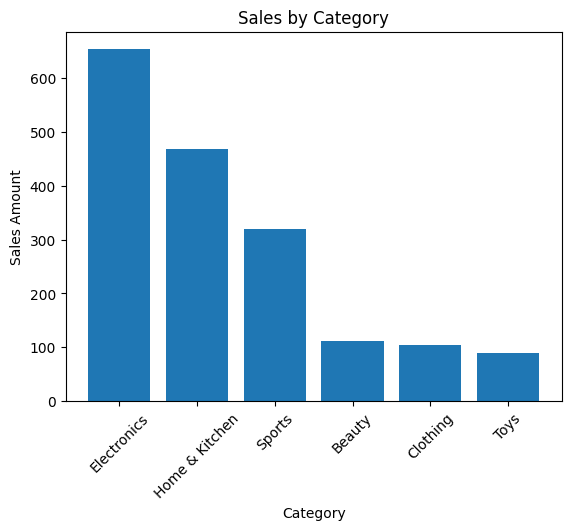

In [24]:
import matplotlib.pyplot as plt

category_sales = df.groupby('Category')['SalesAmount'].sum().sort_values(ascending=False)

plt.bar(category_sales.index, category_sales.values)
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.show()

Electronics had the highest total sales, while Toys had the lowest.

### Chart 2: Sales Over Time

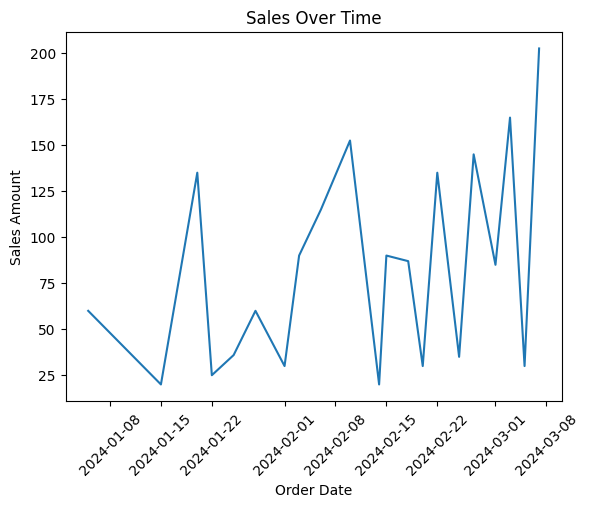

In [25]:
daily_sales = df.groupby('OrderDate')['SalesAmount'].sum().sort_index()

plt.plot(daily_sales.index, daily_sales.values)
plt.title('Sales Over Time')
plt.xlabel('Order Date')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.show()

Sales varied across the period, with the highest daily sales recorded on 7 March 2024.

### Chart 3: Distribution of Order Sales Amounts

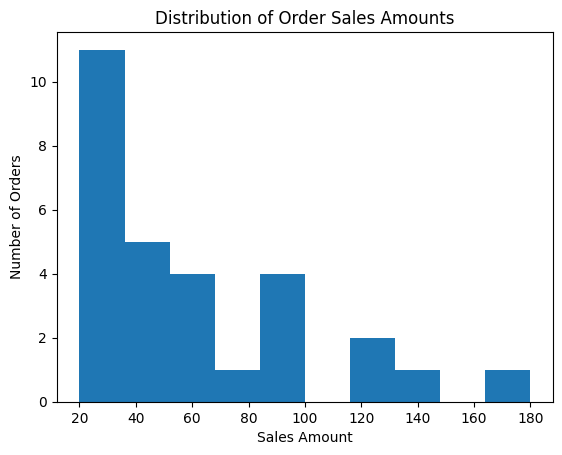

In [26]:
plt.hist(df['SalesAmount'])
plt.title('Distribution of Order Sales Amounts')
plt.xlabel('Sales Amount')
plt.ylabel('Number of Orders')
plt.show()

Most orders had lower sales amounts, with only a few orders above 100.

### Chart 4: Quantity vs Sales Amount

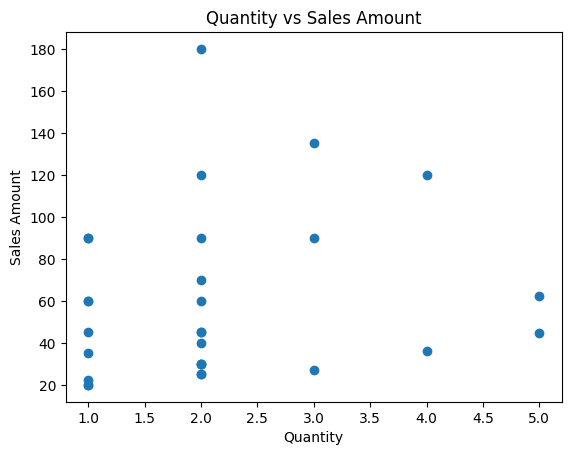

In [27]:
plt.scatter(df['Quantity'], df['SalesAmount'])
plt.title('Quantity vs Sales Amount')
plt.xlabel('Quantity')
plt.ylabel('Sales Amount')
plt.show()

There is no strong relationship between quantity and sales amount because unit price also affects the total.

## Communicate Insights

### Key Findings

- Electronics generated the highest total sales at 652.41.
- Credit Card was the most common payment method with 9 orders.
- South had the highest average order value at 70.69.
- Backpack, Bluetooth Speaker, and Cookware Set had the highest average rating of 5.0.
- The highest daily sales amount was 202.48 on 7 March 2024.

### Recommendation

The business should continue focusing on Electronics and review lower-performing categories, regional differences, and payment preferences when planning future sales.